# Base CNN Training for Posture Classification (FP32)

**Architecture**
- 3 Conv2D layers with BatchNormalization
- Filter progression: [16, 16, 24]
- GlobalAveragePooling2D for efficiency
- Output: Dense(6, softmax)

**Hyperparameters**
- Learning rate: 0.001
- Batch size: 32
- Kernel size: (3, 3)
- L1 regularization: 1e-4
- Early stopping patience: 10

## Imports

In [174]:
import os
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path

# Keras 3
import keras
import keras_tuner
from keras import layers
from keras import regularizers
from keras import optimizers
from keras.utils import to_categorical

# TensorFlow
import tensorflow as tf

# Scikit-learn for metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# Set random seed for reproducibility
np.random.seed(42)
keras.utils.set_random_seed(42)

# Check GPU
print(tf.config.list_physical_devices('GPU'))

# Constant number of postures
NUM_CLASSES = 3

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Loading

In [175]:
# Dataset paths
dataset_dir = Path('../dataset/output')
train_file = dataset_dir / 'train_raw.npz'
val_file = dataset_dir / 'val_raw.npz'
test_file = dataset_dir / 'test_raw.npz'

# Load datasets
train_data = np.load(train_file, allow_pickle=True)
val_data = np.load(val_file, allow_pickle=True)
test_data = np.load(test_file, allow_pickle=True)

# Extract features and labels
X_train_raw = train_data['data']
y_train_raw = train_data['labels']

X_val_raw = val_data['data']
y_val_raw = val_data['labels']

X_test_raw = test_data['data']
y_test_raw = test_data['labels']

print("\nDataset shapes:")
print(f"  Train: {X_train_raw.shape}, labels: {y_train_raw.shape}")
print(f"  Val:   {X_val_raw.shape}, labels: {y_val_raw.shape}")
print(f"  Test:  {X_test_raw.shape}, labels: {y_test_raw.shape}")


Dataset shapes:
  Train: (40325, 64), labels: (40325,)
  Val:   (20162, 64), labels: (20162,)
  Test:  (40326, 64), labels: (40326,)


## Data Preprocessing

In [176]:
# Encode labels as integers 0-5
label_encoder = LabelEncoder()
y_train_int = label_encoder.fit_transform(y_train_raw)
y_val_int = label_encoder.transform(y_val_raw)
y_test_int = label_encoder.transform(y_test_raw)

print("Label encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {label} -> {i}")

# One-hot encode labels
y_train = to_categorical(y_train_int, num_classes=NUM_CLASSES)
y_val = to_categorical(y_val_int, num_classes=NUM_CLASSES)
y_test = to_categorical(y_test_int, num_classes=NUM_CLASSES)

print(f"\nOne-hot encoded shape: {y_train.shape[1]}")

Label encoding:
  lateral_L -> 0
  lateral_R -> 1
  supine -> 2

One-hot encoded shape: 3


In [177]:
# Reshape data from (N, 64) to (N, 8, 8, 1)
X_train = X_train_raw.reshape(-1, 8, 8, 1).astype('float32')
X_val = X_val_raw.reshape(-1, 8, 8, 1).astype('float32')
X_test = X_test_raw.reshape(-1, 8, 8, 1).astype('float32')

print("Reshaped data:")
print(f"  Train: {X_train.shape}")
print(f"  Val:   {X_val.shape}")
print(f"  Test:  {X_test.shape}")
print(f"\nData range: [{X_train.min():.4f}, {X_train.max():.4f}]")
print(f"Data dtype: {X_train.dtype}")

Reshaped data:
  Train: (40325, 8, 8, 1)
  Val:   (20162, 8, 8, 1)
  Test:  (40326, 8, 8, 1)

Data range: [0.0000, 235.8969]
Data dtype: float32


## Model Definition

In [250]:
def create_model(hp=None, input_shape=(8, 8, 1), num_classes=NUM_CLASSES):
    """
    Create CNN model for posture classification with optional hyperparameter tuning.

    Supports both fixed architecture and hyperparameter tuning modes via Keras Tuner.

    Args:
        hp: Optional keras_tuner.HyperParameters object for tuning
        input_shape: Input tensor shape (H, W, C), default (8, 8, 1)
        num_classes: Number of output classes, default NUM_CLASSES

    Returns:
        Compiled Keras Model instance
    """
    # Guard clause: Determine parameters based on mode
    if hp is None:
        # Fixed architecture mode
        filters_list = [16, 16, 24]
        kernel_size = 3
        learning_rate = 0.001
        model_name = "posture_classifier_base"
    else:
        # Hyperparameter tuning mode
        filters_list = [
            hp.Int("filters_1", min_value=4, max_value=64, step=8),
            hp.Int("filters_2", min_value=4, max_value=64, step=8),
            hp.Int("filters_3", min_value=8, max_value=128, step=8),
        ]
        # kernel_size = hp.Choice("kernel_size", values=[3, 5]
        kernel_size = 3
        learning_rate = hp.Choice("learning_rate", values=[0.001, 0.0001])
        model_name = "posture_classifier_tuned"

    # Input layer
    inputs = keras.Input(shape=input_shape, name="pressure_map")

    # Build 3 conv blocks using loop
    x = inputs  # Start with inputs
    for i, filters in enumerate(filters_list, 1):
        # Conv layer
        x = layers.Conv2D(
            filters=filters,
            kernel_size=(kernel_size, kernel_size),
            kernel_initializer="lecun_uniform",
            kernel_regularizer=regularizers.l1(1e-4),
            use_bias=False,
            name=f"conv_{i}",
        )(x)

        # Batch normalization
        x = layers.BatchNormalization(name=f"bn_conv_{i}")(x)

        # Activation
        x = layers.Activation("relu", name=f"conv_act_{i}")(x)

    # MaxPooling (after all conv blocks)
    x = layers.MaxPooling2D(pool_size=(2, 2), name="pool_3")(x)

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)

    # Output layer
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    # Create model
    model = keras.Model(inputs=inputs, outputs=outputs, name=model_name)

    # Always compile (simplified - no conditional logic)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

In [179]:
# Taken from part6_cnns.ipynb (also used in Scr_1_TensorFlowCNN.py)
def check_layer_trainable_params(model):
    for layer in model.layers:
        if layer.__class__.__name__ in ['Conv2D', 'Dense']:
            w = layer.get_weights()[0]
            layersize = np.prod(w.shape)
            print("{}: {}".format(layer.name, layersize))  # 0 = weights, 1 = biases
            if layersize > 4096:  # assuming that shape[0] is batch, i.e., 'None'
                print("Layer {} is too large ({}), are you sure you want to train?".format(layer.name, layersize))

## Training Configuration

In [180]:
# Define callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='best_base_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks configured:")
for cb in callbacks:
    print(f"  - {cb.__class__.__name__}")

Callbacks configured:
  - EarlyStopping
  - ReduceLROnPlateau
  - ModelCheckpoint


In [181]:
# Training function
def train_model(model, batch_size=32, max_epochs=50):
    start_time = time.time()
    
    history = model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=max_epochs,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1)
    
    training_time = time.time() - start_time
    
    print(f"\nTraining completed in {training_time/60:.2f} minutes")
    
    return history

In [182]:
# History training function
def plot_training_history(history, save=False):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot loss
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    # Plot accuracy
    axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Training and Validation Accuracy', fontsize=14)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    if save:
        plt.savefig(f'training_{history}.png', dpi=300, bbox_inches='tight')

## Base Model

In [183]:
base_model = create_model()
base_model.summary()

check_layer_trainable_params(base_model)

Model: "posture_classifier_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 6, 6, 16)       │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_1 (BatchNormalization)  │ (None, 6, 6, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_1 (Activation)         │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 4, 4, 16)       │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_2 (BatchNormalization)  │ (None, 4, 4, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_2 (Activation)         │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 2, 2, 24)       │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_3 (BatchNormalization)  │ (None, 2, 2, 24)       │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_3 (Activation)         │ (None, 2, 2, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (MaxPooling2D)           │ (None, 1, 1, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 24)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            75 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,203 (24.23 KB)

 Trainable params: 6,091 (23.79 KB)

 Non-trainable params: 112 (448.00 B)

conv_1: 144
conv_2: 2304
conv_3: 3456
output: 72


### Training

Epoch 1/50


I0000 00:00:1776980187.050781   28169 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7309921__.47


1234/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6395 - loss: 0.8508

I0000 00:00:1776980190.180118   28171 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7309921__.47


1261/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6411 - loss: 0.8476
Epoch 1: val_loss improved from None to 0.56934, saving model to best_base_model.keras

Epoch 1: finished saving model to best_base_model.keras
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7169 - loss: 0.7026 - val_accuracy: 0.7791 - val_loss: 0.5693 - learning_rate: 0.0010
Epoch 2/50
1256/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7917 - loss: 0.5456
Epoch 2: val_loss improved from 0.56934 to 0.48948, saving model to best_base_model.keras

Epoch 2: finished saving model to best_base_model.keras
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8012 - loss: 0.5279 - val_accuracy: 0.8170 - val_loss: 0.4895 - learning_rate: 0.0010
Epoch 3/50
1241/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8200 - loss: 0.4848
Epoch 3: val_loss improved from 0.48948 to 0.44837, saving model to best_base_model.keras

Epoch 3: finished saving model to best_base_model.keras
1261/1261 ━━━━━━━━━━━━━

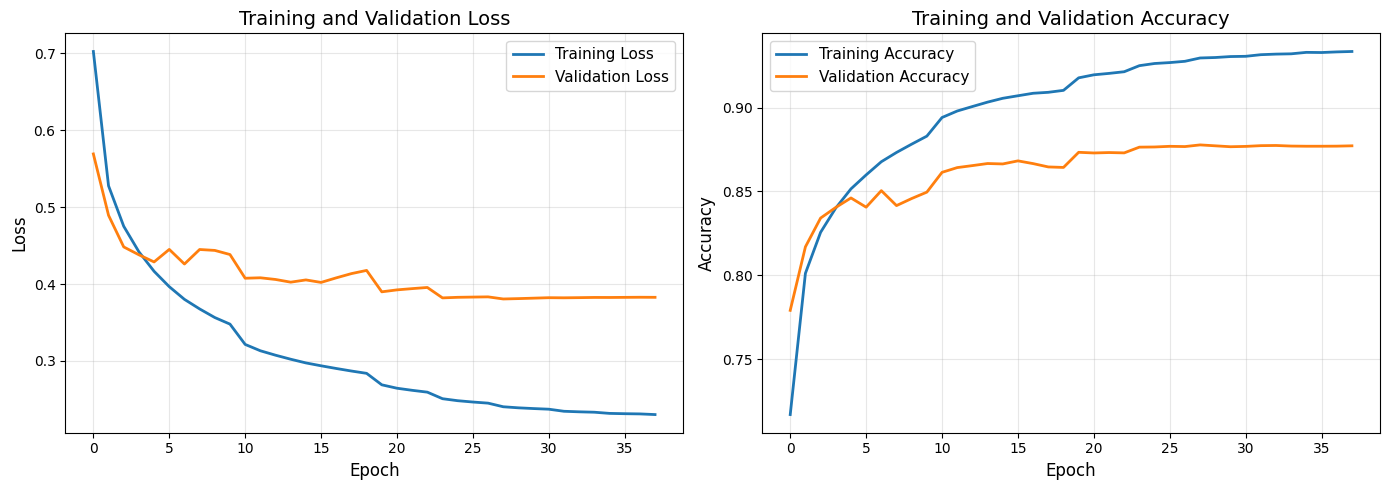

In [184]:
base_history = train_model(base_model)
plot_training_history(base_history)

## Tuned Model

Hyperparameter optimization (KerasTuner)

In [ ]:
tuner = keras_tuner.Hyperband(
    hypermodel=create_model,
    objective='val_accuracy',
    max_epochs=20,
    factor=3,
    hyperband_iterations=2,
    overwrite=False,
    directory='tuning',
    project_name='posture_cnn',
    )

tuner.search_space_summary()

Search space summary
Default search space size: 4
filters_1 (Int)
{'default': None, 'conditions': [], 'min_value': 4, 'max_value': 64, 'step': 8, 'sampling': 'linear'}
filters_2 (Int)
{'default': None, 'conditions': [], 'min_value': 4, 'max_value': 64, 'step': 8, 'sampling': 'linear'}
filters_3 (Int)
{'default': None, 'conditions': [], 'min_value': 8, 'max_value': 128, 'step': 8, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0001], 'ordered': True}


In [252]:
tuner.search(X_train, y_train, epochs=10, validation_data=(X_val, y_val))
tuned_model = tuner.get_best_models()[0]

tuned_model.summary()

check_layer_trainable_params(tuned_model)

Trial 60 Complete [00h 01m 00s]
val_accuracy: 0.8695566058158875

Best val_accuracy So Far: 0.8944053053855896
Total elapsed time: 00h 27m 45s


Model: "posture_classifier_tuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 6, 6, 60)       │           540 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_1 (BatchNormalization)  │ (None, 6, 6, 60)       │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_1 (Activation)         │ (None, 6, 6, 60)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 4, 4, 44)       │        23,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_2 (BatchNormalization)  │ (None, 4, 4, 44)       │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_2 (Activation)         │ (None, 4, 4, 44)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 2, 2, 96)       │        38,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_3 (BatchNormalization)  │ (None, 2, 2, 96)       │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_3 (Activation)         │ (None, 2, 2, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (MaxPooling2D)           │ (None, 1, 1, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 96)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,407 (247.68 KB)

 Trainable params: 63,007 (246.12 KB)

 Non-trainable params: 400 (1.56 KB)

conv_1: 540
conv_2: 23760
Layer conv_2 is too large (23760), are you sure you want to train?
conv_3: 38016
Layer conv_3 is too large (38016), are you sure you want to train?
output: 288


### Training

Epoch 1/50


1231/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9693 - loss: 0.3062
Epoch 1: val_loss did not improve from 0.37832
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9760 - loss: 0.2871 - val_accuracy: 0.9111 - val_loss: 0.4836 - learning_rate: 1.2500e-04
Epoch 2/50
1244/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9884 - loss: 0.2547
Epoch 2: val_loss did not improve from 0.37832
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9907 - loss: 0.2486 - val_accuracy: 0.9128 - val_loss: 0.4768 - learning_rate: 1.2500e-04
Epoch 3/50
1231/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9939 - loss: 0.2362
Epoch 3: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 3: val_loss did not improve from 0.37832
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9952 - loss: 0.2315 - val_accuracy: 0.9126 - val_loss: 0.4749 - learning_rate: 1.2500e-04
Epoch 4/50
1241/1261 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9964 - loss: 0.2227
E

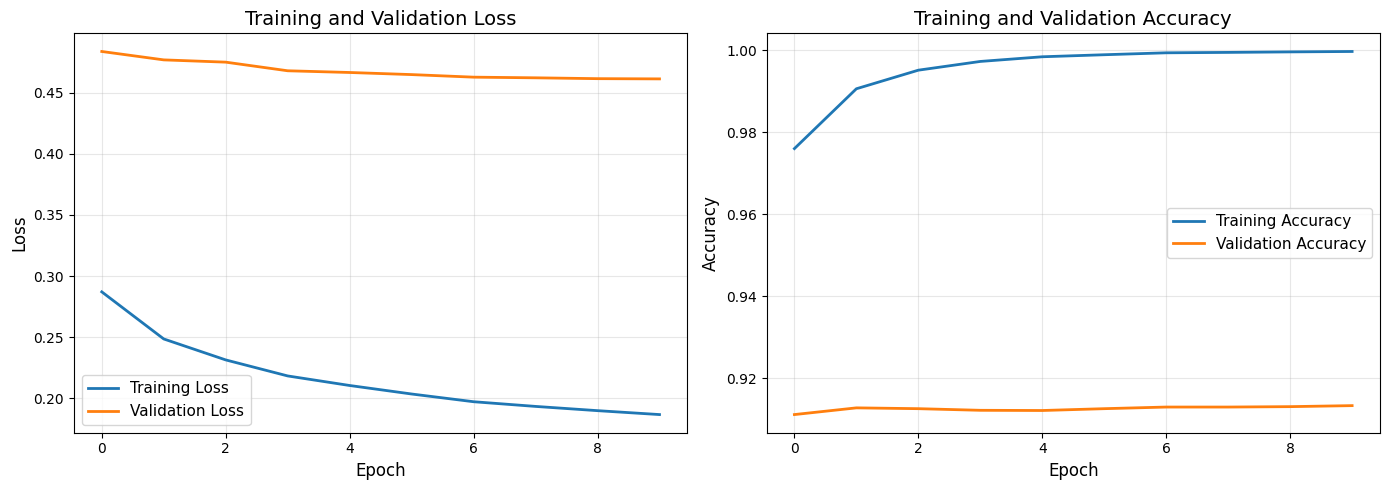

In [254]:
tuned_history = train_model(tuned_model)
plot_training_history(tuned_history)

## Model Evaluation

Accuracy Comparison (Evaluate on test set)

In [261]:
# Base model
base_test_loss, base_test_accuracy = base_model.evaluate(X_test, y_test, verbose=0)

print("\nTest Base Model:")
print(f"  Loss: {base_test_loss:.4f}")
print(f"  Accuracy: {base_test_accuracy*100:.2f}%")

# Best model
tuned_test_loss, tuned_test_accuracy = tuned_model.evaluate(X_test, y_test, verbose=0)

print("\nTest Best Model:")
print(f"  Loss: {tuned_test_loss:.4f}")
print(f"  Accuracy: {tuned_test_accuracy*100:.2f}%")


Test Base Model:
  Loss: 0.3735
  Accuracy: 87.78%

Test Best Model:
  Loss: 0.4759
  Accuracy: 91.41%


Metrics per classification

In [262]:
def class_report_metric(model):
    # Get predictions
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred_proba, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)

    # Classification report
    print(f"\nClassification Report for `{model.name}`:")
    print("="*70)
    print(classification_report(
        y_true_classes, 
        y_pred_classes, 
        target_names=label_encoder.classes_,
        digits=4
    ))

### Base Model

In [263]:
class_report_metric(base_model)


Classification Report for `posture_classifier_base`:
              precision    recall  f1-score   support

   lateral_L     0.8891    0.8947    0.8919     17406
   lateral_R     0.8682    0.8711    0.8696     12678
      supine     0.8705    0.8574    0.8639     10242

    accuracy                         0.8778     40326
   macro avg     0.8759    0.8744    0.8752     40326
weighted avg     0.8778    0.8778    0.8778     40326



### Tuned Model

In [264]:
class_report_metric(tuned_model)


Classification Report for `posture_classifier_tuned`:
              precision    recall  f1-score   support

   lateral_L     0.9112    0.9343    0.9226     17406
   lateral_R     0.9115    0.9104    0.9110     12678
      supine     0.9228    0.8844    0.9032     10242

    accuracy                         0.9141     40326
   macro avg     0.9152    0.9097    0.9123     40326
weighted avg     0.9142    0.9141    0.9140     40326



## Model Saving

In [265]:
def save_model(model):
    # Save base model in Keras 3 format
    model_path = f'output/{model.name}.keras'
    model.save(model_path)

    print(f"\nModel saved to: {model_path}")

    # Verify saved model
    loaded_model = keras.models.load_model(model_path)
    print("\nVerification:")
    print(f"  Loaded successfully: {loaded_model is not None}")
    print(f"  Model name: {loaded_model.name}")
    print(f"  Total parameters: {loaded_model.count_params():,}")

In [266]:
save_model(base_model)
save_model(tuned_model)


Model saved to: output/posture_classifier_base.keras

Verification:
  Loaded successfully: True
  Model name: posture_classifier_base
  Total parameters: 6,203

Model saved to: output/posture_classifier_tuned.keras

Verification:
  Loaded successfully: True
  Model name: posture_classifier_tuned
  Total parameters: 63,407
